<a href="https://colab.research.google.com/github/gonatae2-hash/-/blob/main/%EB%82%98%EC%82%AC_%EA%B2%80%EC%B6%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 설치



In [ ]:
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 81.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


ultralytics → YOLOv8 사용하기 위한 패키지

roboflow → Roboflow에서 데이터셋 다운받기 위한 패키지

# 2. 데이터 셋 다운로드

In [ ]:
from roboflow import Roboflow

from google.colab import userdata
rf = Roboflow(api_key=userdata.get('ROBOFLOW_API_KEY'))
project = rf.workspace("gunadarma-university-oo4uc").project("screw-defect-detection")
dataset = project.version(4).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Screw-Defect-Detection-4 in yolov8:: 100%|██████████| 1687/1687 [00:00<00:00, 10654.43it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# 3. YOLOv8 학습

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # nano 모델 (Colab에서 빠름)

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="screw_defect",
    patience=10
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Screw-Defect-Detection-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=screw_defect, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f057dad17c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

# 4. 결과 확인

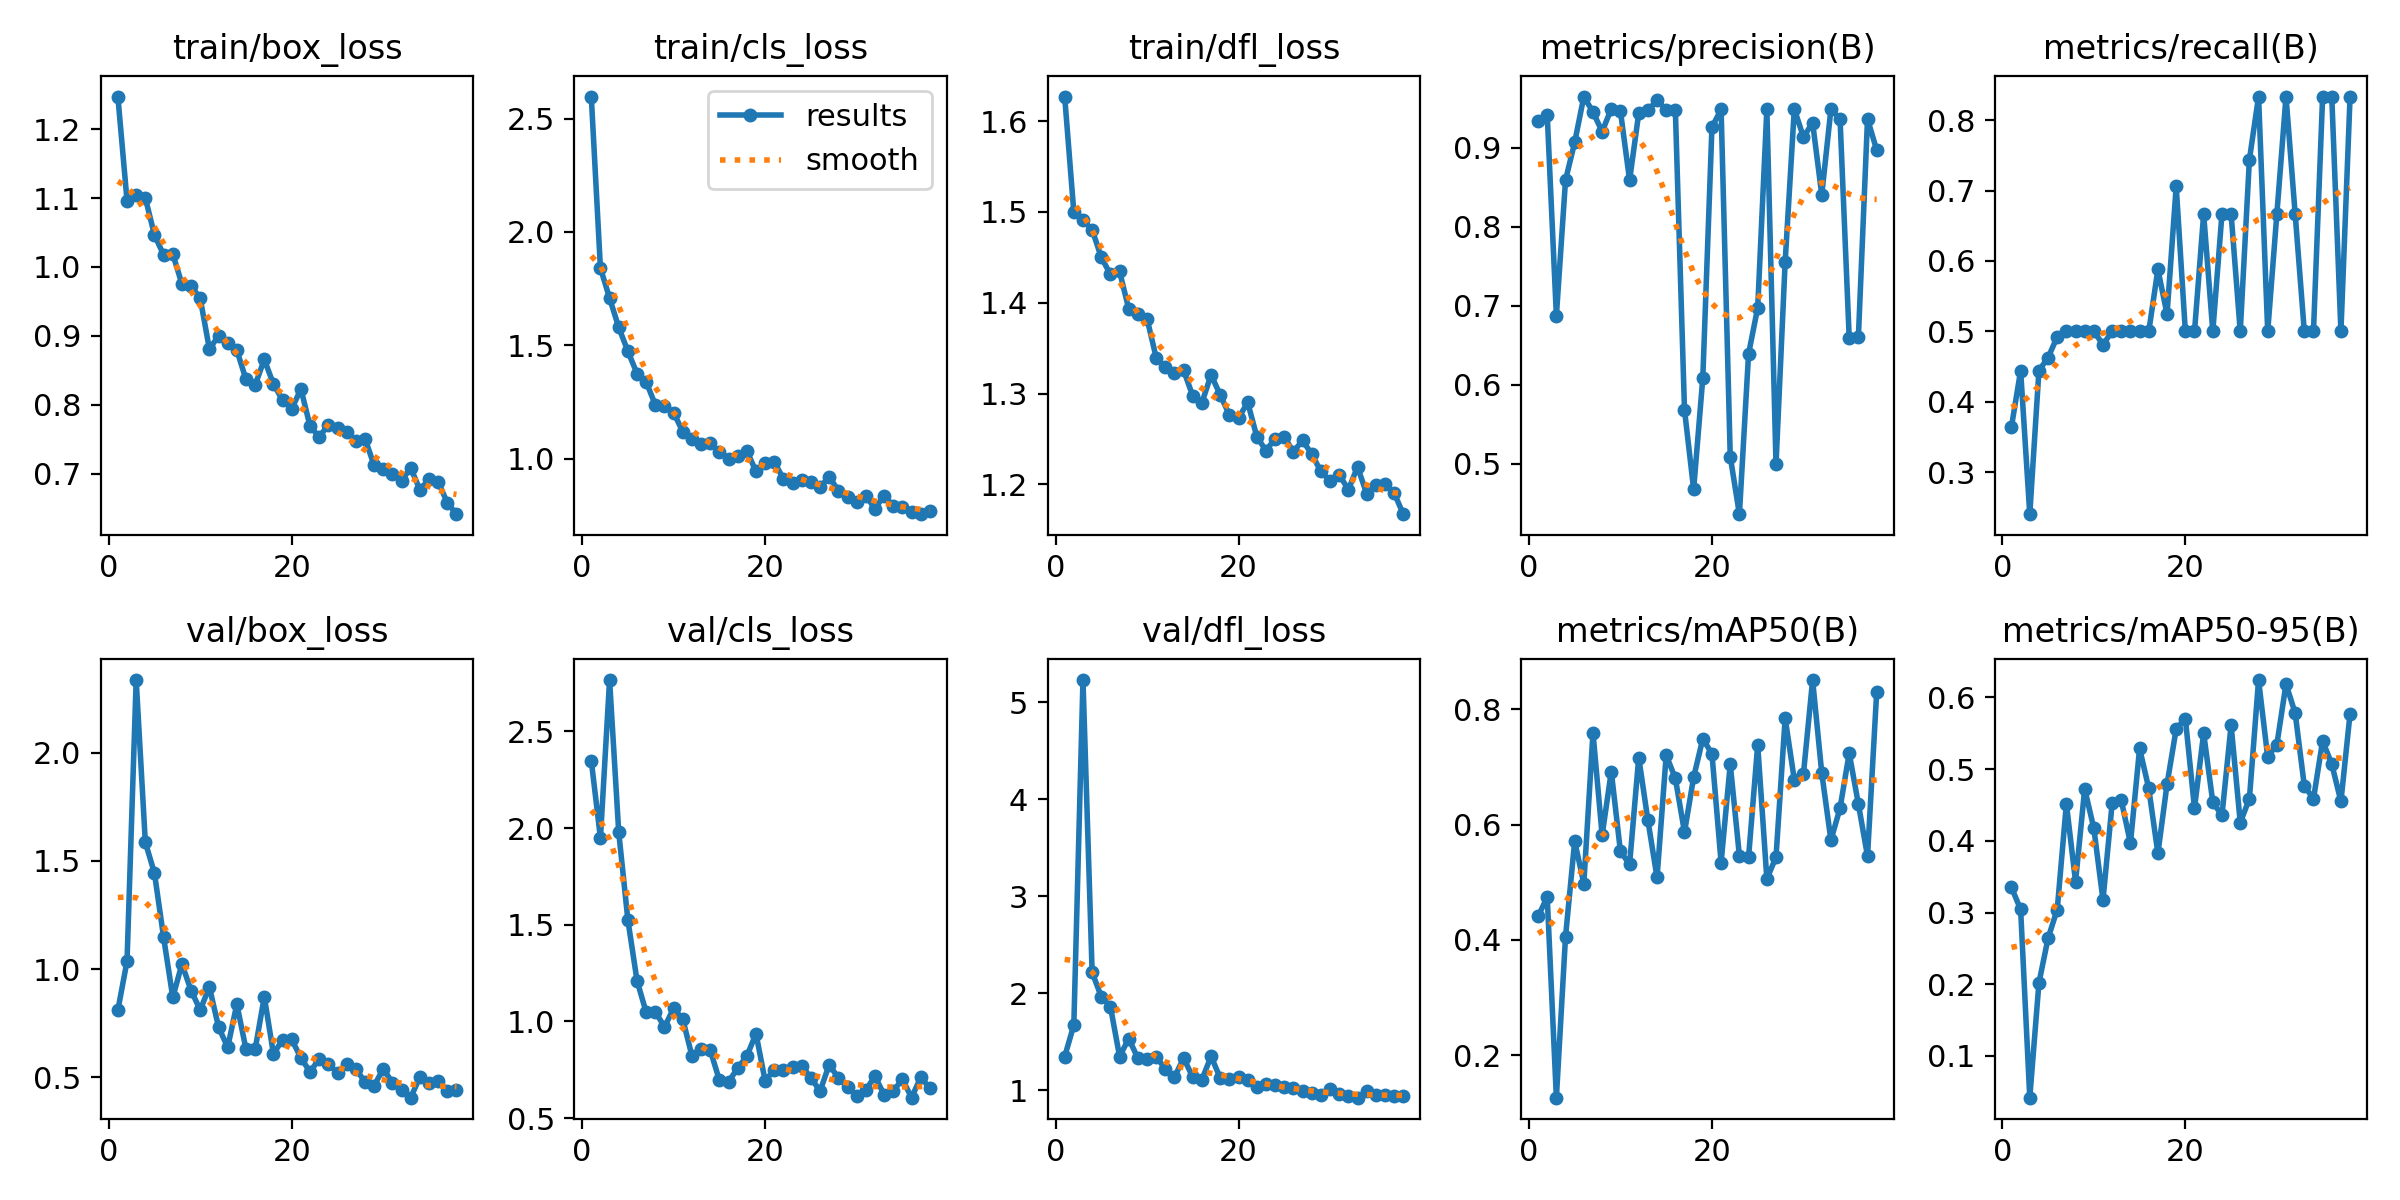

In [ ]:
import glob
from IPython.display import Image, display

# 학습 결과 그래프
display(Image("/content/runs/detect/screw_defect/results.png"))

정확도(mAP), 손실값(loss) 변화 그래프 확인

# 5. 테스트 이미지 추론


image 1/30 /content/Screw-Defect-Detection-4/valid/images/manipulated_front003_png.rf.41917c15a06e25af43de752f09abe218.jpg: 640x640 1 OK, 8.8ms
image 2/30 /content/Screw-Defect-Detection-4/valid/images/manipulated_front005_png.rf.01af1d499be126d8b13c4f331351e809.jpg: 640x640 1 OK, 7.2ms
image 3/30 /content/Screw-Defect-Detection-4/valid/images/manipulated_front008_png.rf.90e179fd5d4c6b257add4417974b9166.jpg: 640x640 1 OK, 7.2ms
image 4/30 /content/Screw-Defect-Detection-4/valid/images/ok005_png.rf.d00ef1316ac303efaec717ec81d4701d.jpg: 640x640 1 OK, 7.2ms
image 5/30 /content/Screw-Defect-Detection-4/valid/images/ok014_png.rf.46209c4db04c031d748b79ffa1ce703d.jpg: 640x640 1 OK, 1 thread, 7.1ms
image 6/30 /content/Screw-Defect-Detection-4/valid/images/ok025_png.rf.cef172435249052ebb26f7d81c7969a9.jpg: 640x640 1 OK, 7.2ms
image 7/30 /content/Screw-Defect-Detection-4/valid/images/ok027_png.rf.2cee70182d5bc1e5fbad2422a9f82d5e.jpg: 640x640 1 OK, 7.2ms
image 8/30 /content/Screw-Defect-Detectio

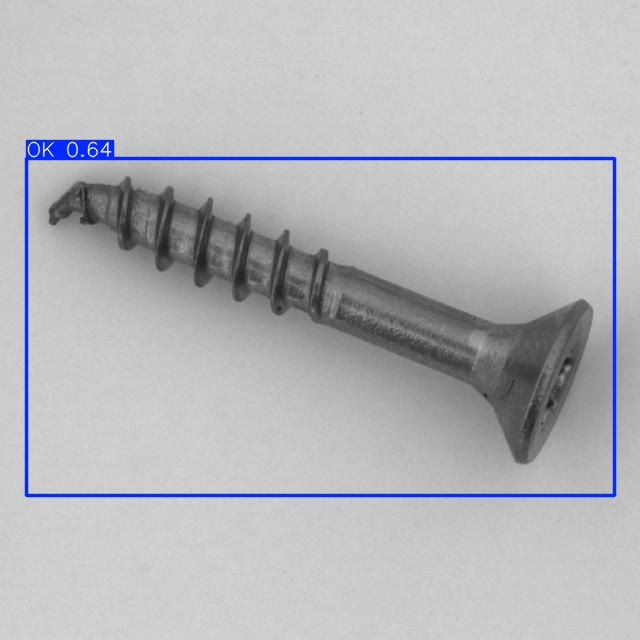

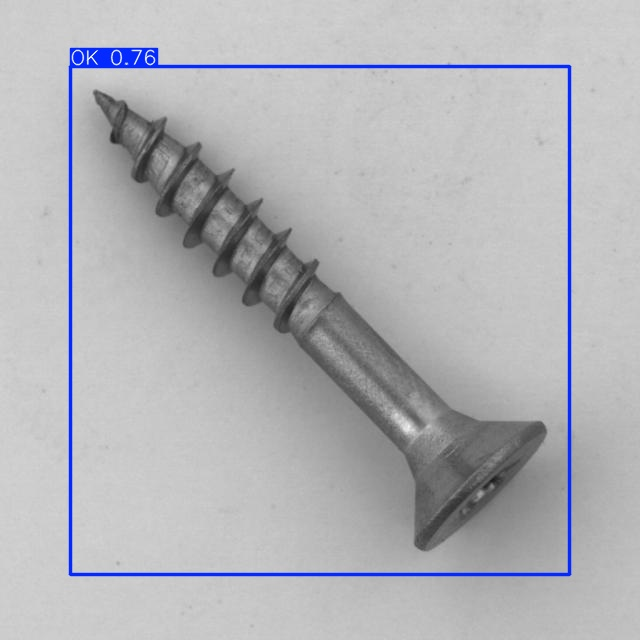

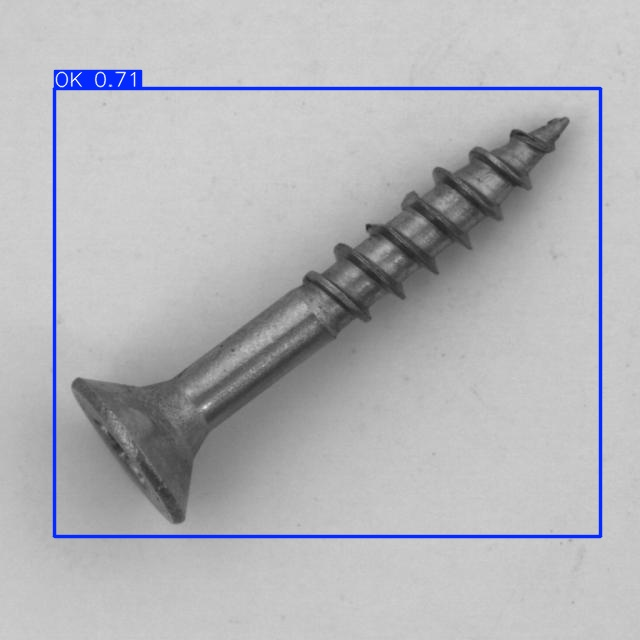

In [ ]:
model = YOLO("/content/runs/detect/screw_defect/weights/best.pt")

results = model.predict(
    source=f"{dataset.location}/valid/images",
    conf=0.5,
    save=True
)

# 결과 이미지 확인
images = glob.glob("/content/runs/detect/predict/*.jpg")[:3]
for img in images:
    display(Image(img))

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key=userdata.get('ROBOFLOW_API_KEY'))
project = rf.workspace("s-workspace-ogsll").project("screw-detection-jp4ck")
dataset2 = project.version(2).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 0.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to screw-detection-2 in yolov8:: 100%|██████████| 183/183 [00:00<00:00, 9484.57it/s]


In [ ]:
from ultralytics import YOLO

model2 = YOLO("yolov8n.pt")

model2.train(
    data=dataset2.location + "/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="screw_combined",
    patience=10
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/screw-detection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=screw_combined, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f064dd43a40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display

model2 = YOLO("/content/runs/detect/screw_combined/weights/best.pt")

test_my_screws = [
    "/drive/MyDrive/WIN_20260424_10_53_05_Pro.jpg"
]

for img_path in test_my_screws:
    print(f"\n--- {img_path.split('/')[-1]} ---")
    results = model2.predict(img_path, conf=0.3, save=True, verbose=False)
    for r in results:
        for box in r.boxes:
            print(f"클래스: {r.names[int(box.cls[0])]} | 신뢰도: {float(box.conf[0]):.2f}")


--- WIN_20260424_10_53_05_Pro.jpg ---
Results saved to /content/runs/detect/predict-8


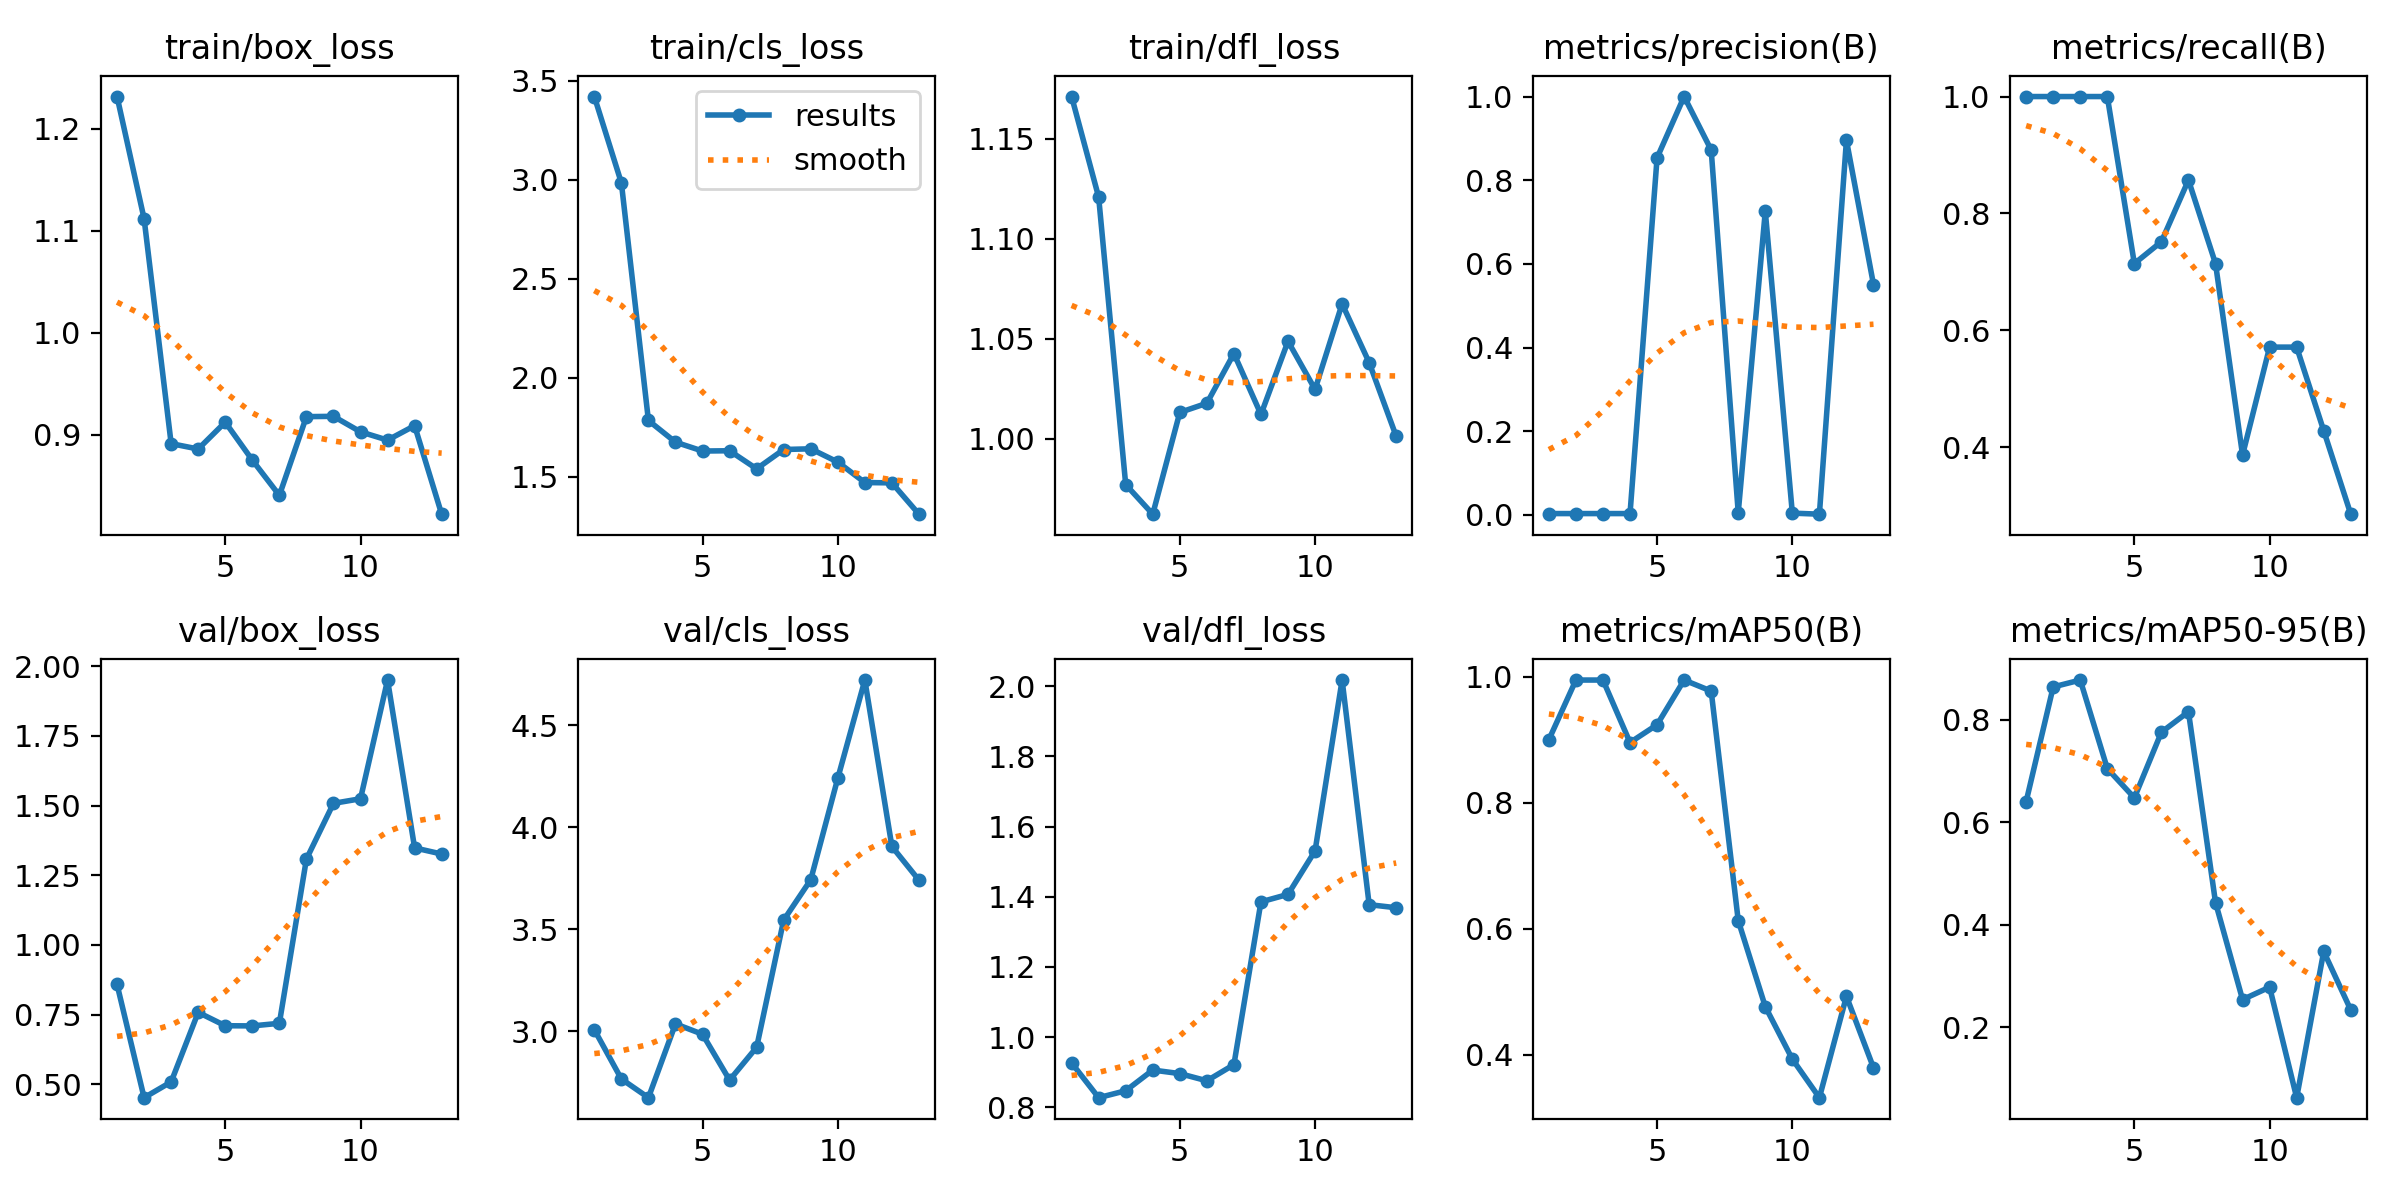

In [ ]:
from IPython.display import Image, display
display(Image("/content/runs/detect/screw_combined/results.png"))

In [ ]:
import os
import shutil

# 두 데이터셋 경로
dataset1_path = "/content/Screw-Defect-Detection-4"  # Gunadarma
dataset2_path = dataset2.location  # 내 나사

# 합칠 폴더 생성
os.makedirs("/content/combined/train/images", exist_ok=True)
os.makedirs("/content/combined/train/labels", exist_ok=True)
os.makedirs("/content/combined/valid/images", exist_ok=True)
os.makedirs("/content/combined/valid/labels", exist_ok=True)

# dataset1 복사
for split in ["train", "valid"]:
    for file in os.listdir(f"{dataset1_path}/{split}/images"):
        shutil.copy(f"{dataset1_path}/{split}/images/{file}", f"/content/combined/{split}/images/{file}")
    for file in os.listdir(f"{dataset1_path}/{split}/labels"):
        shutil.copy(f"{dataset1_path}/{split}/labels/{file}", f"/content/combined/{split}/labels/{file}")

# dataset2 복사
for split in ["train", "valid"]:
    for file in os.listdir(f"{dataset2_path}/{split}/images"):
        shutil.copy(f"{dataset2_path}/{split}/images/{file}", f"/content/combined/{split}/images/my_{file}")
    for file in os.listdir(f"{dataset2_path}/{split}/labels"):
        shutil.copy(f"{dataset2_path}/{split}/labels/{file}", f"/content/combined/{split}/labels/my_{file}")

print("합치기 완료!")

합치기 완료!


In [ ]:
yaml_content = """
train: /content/combined/train/images
val: /content/combined/valid/images

nc: 5
names: ['OK', 'manipulated', 'scratch', 'thread', 'screw']
"""

with open("/content/combined/data.yaml", "w") as f:
    f.write(yaml_content)

print("yaml 생성 완료!")

yaml 생성 완료!


In [ ]:
from ultralytics import YOLO

model3 = YOLO("yolov8n.pt")

model3.train(
    data="/content/combined/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="screw_final",
    patience=10
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/combined/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=screw_final, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f057c797380>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

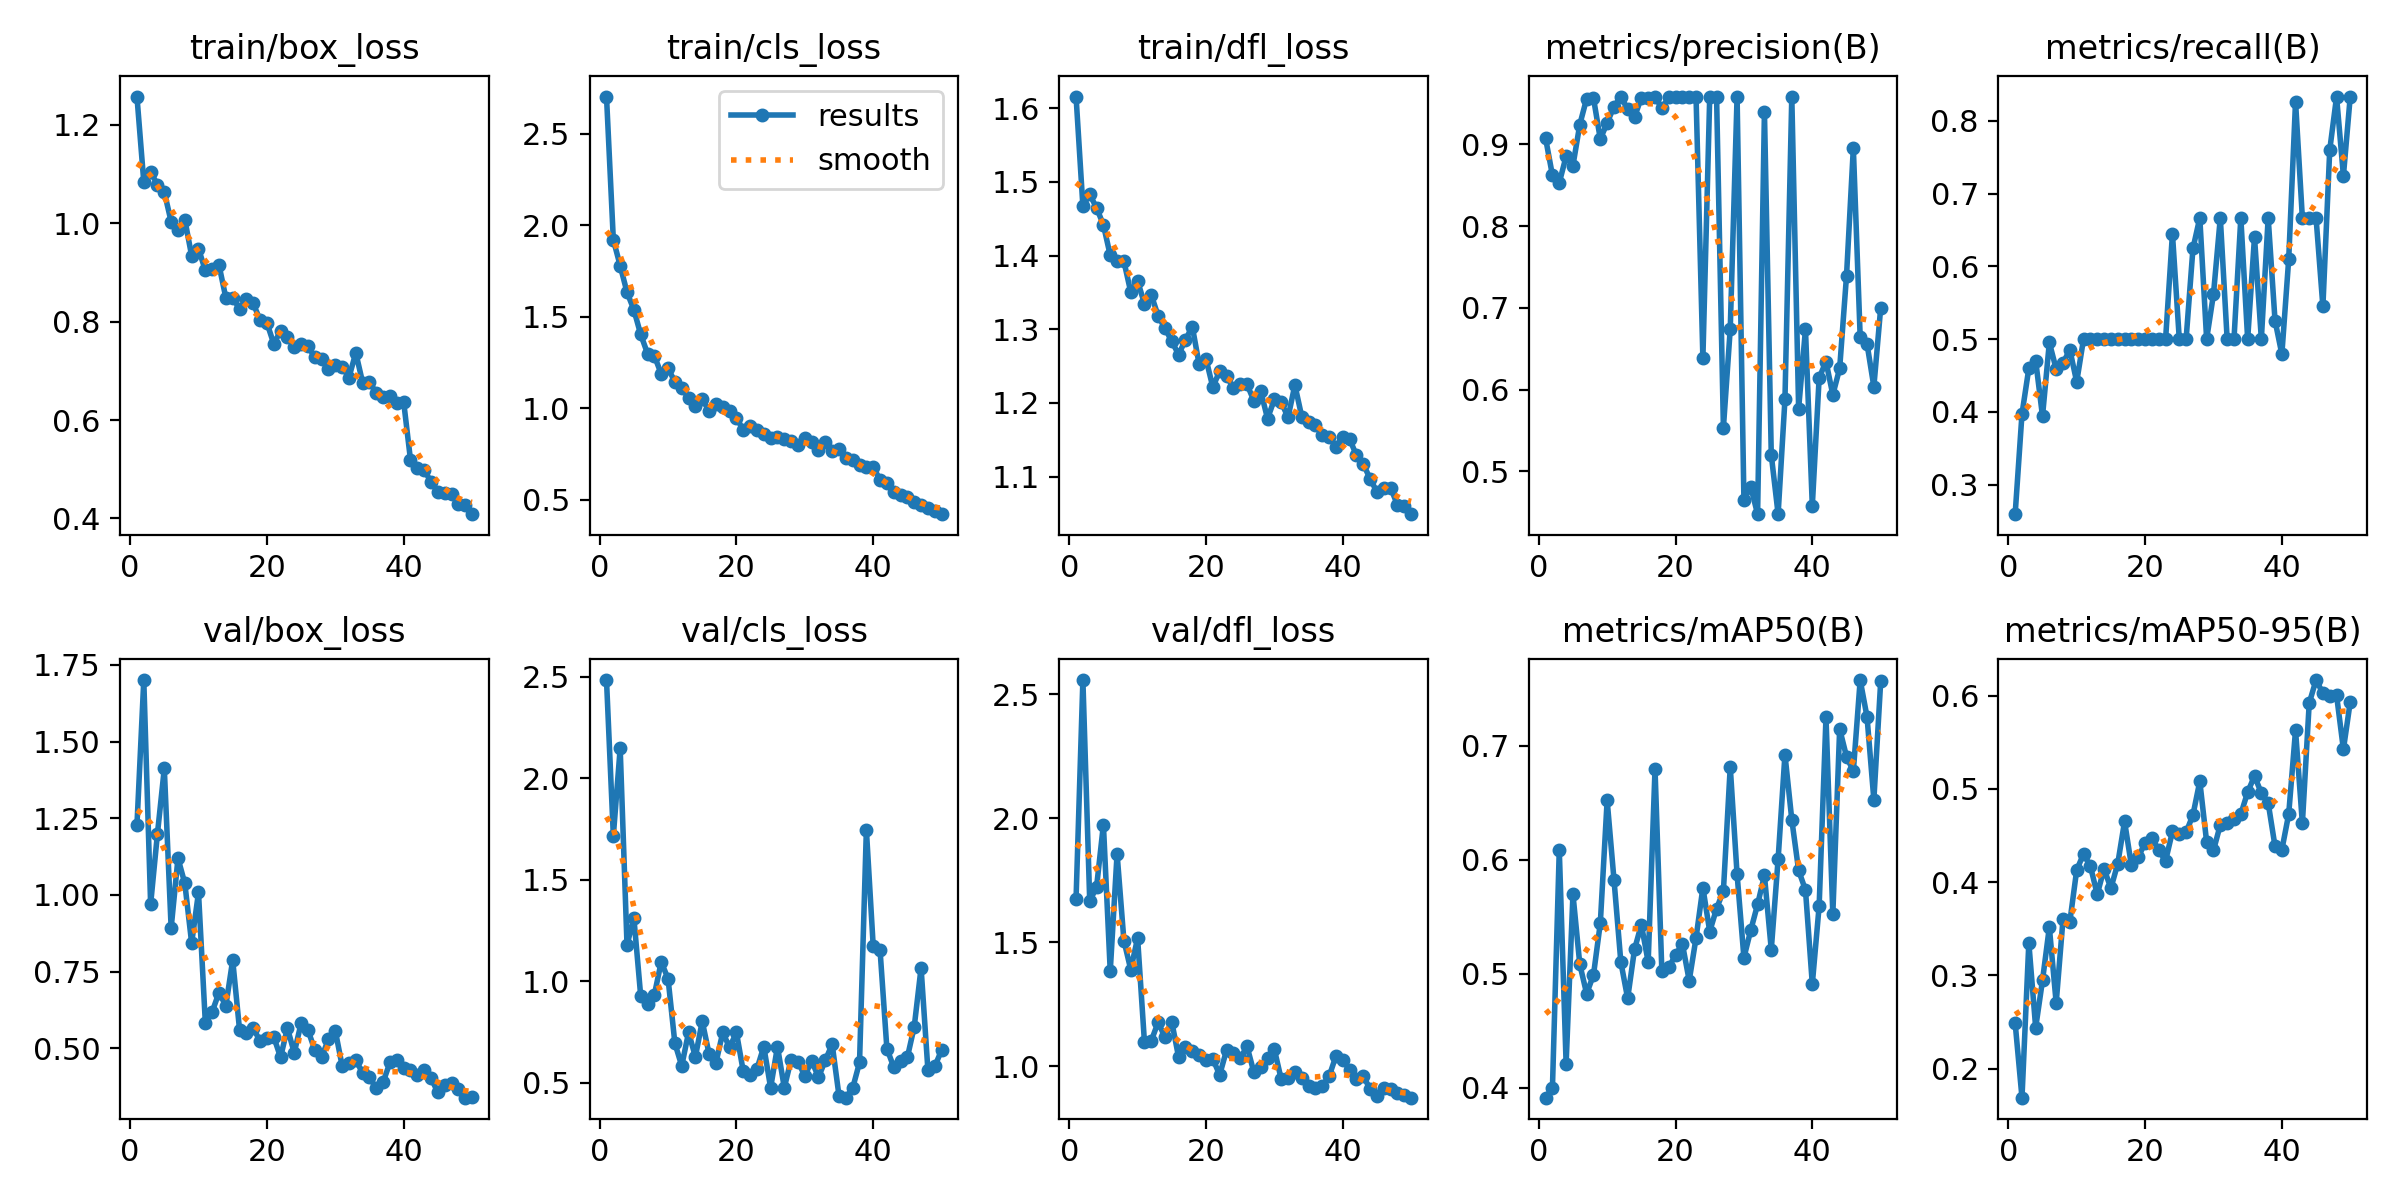

In [ ]:
from IPython.display import Image, display
display(Image("/content/runs/detect/screw_final/results.png"))

내 나사 이미지로 테스트

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import glob

model3 = YOLO("/content/runs/detect/screw_final/weights/best.pt")

test_my_screws = [
    "/drive/MyDrive/WIN_20260424_10_37_42_Pro.jpg",
    "/drive/MyDrive/WIN_20260424_10_37_50_Pro.jpg",
    "/drive/MyDrive/WIN_20260424_10_37_55_Pro.jpg"
]

for img_path in test_my_screws:
    print(f"\n--- {img_path.split('/')[-1]} ---")
    results = model3.predict(img_path, conf=0.3, iou=0.3, save=True, verbose=False)
    for r in results:
        if len(r.boxes) == 0:
            print("검출 없음")
        for box in r.boxes:
            print(f"클래스: {r.names[int(box.cls[0])]} | 신뢰도: {float(box.conf[0]):.2f}")


--- WIN_20260424_10_37_42_Pro.jpg ---
Results saved to /content/runs/detect/predict-10
클래스: OK | 신뢰도: 0.89

--- WIN_20260424_10_37_50_Pro.jpg ---
Results saved to /content/runs/detect/predict-10
클래스: OK | 신뢰도: 0.67

--- WIN_20260424_10_37_55_Pro.jpg ---
Results saved to /content/runs/detect/predict-10
클래스: OK | 신뢰도: 0.92


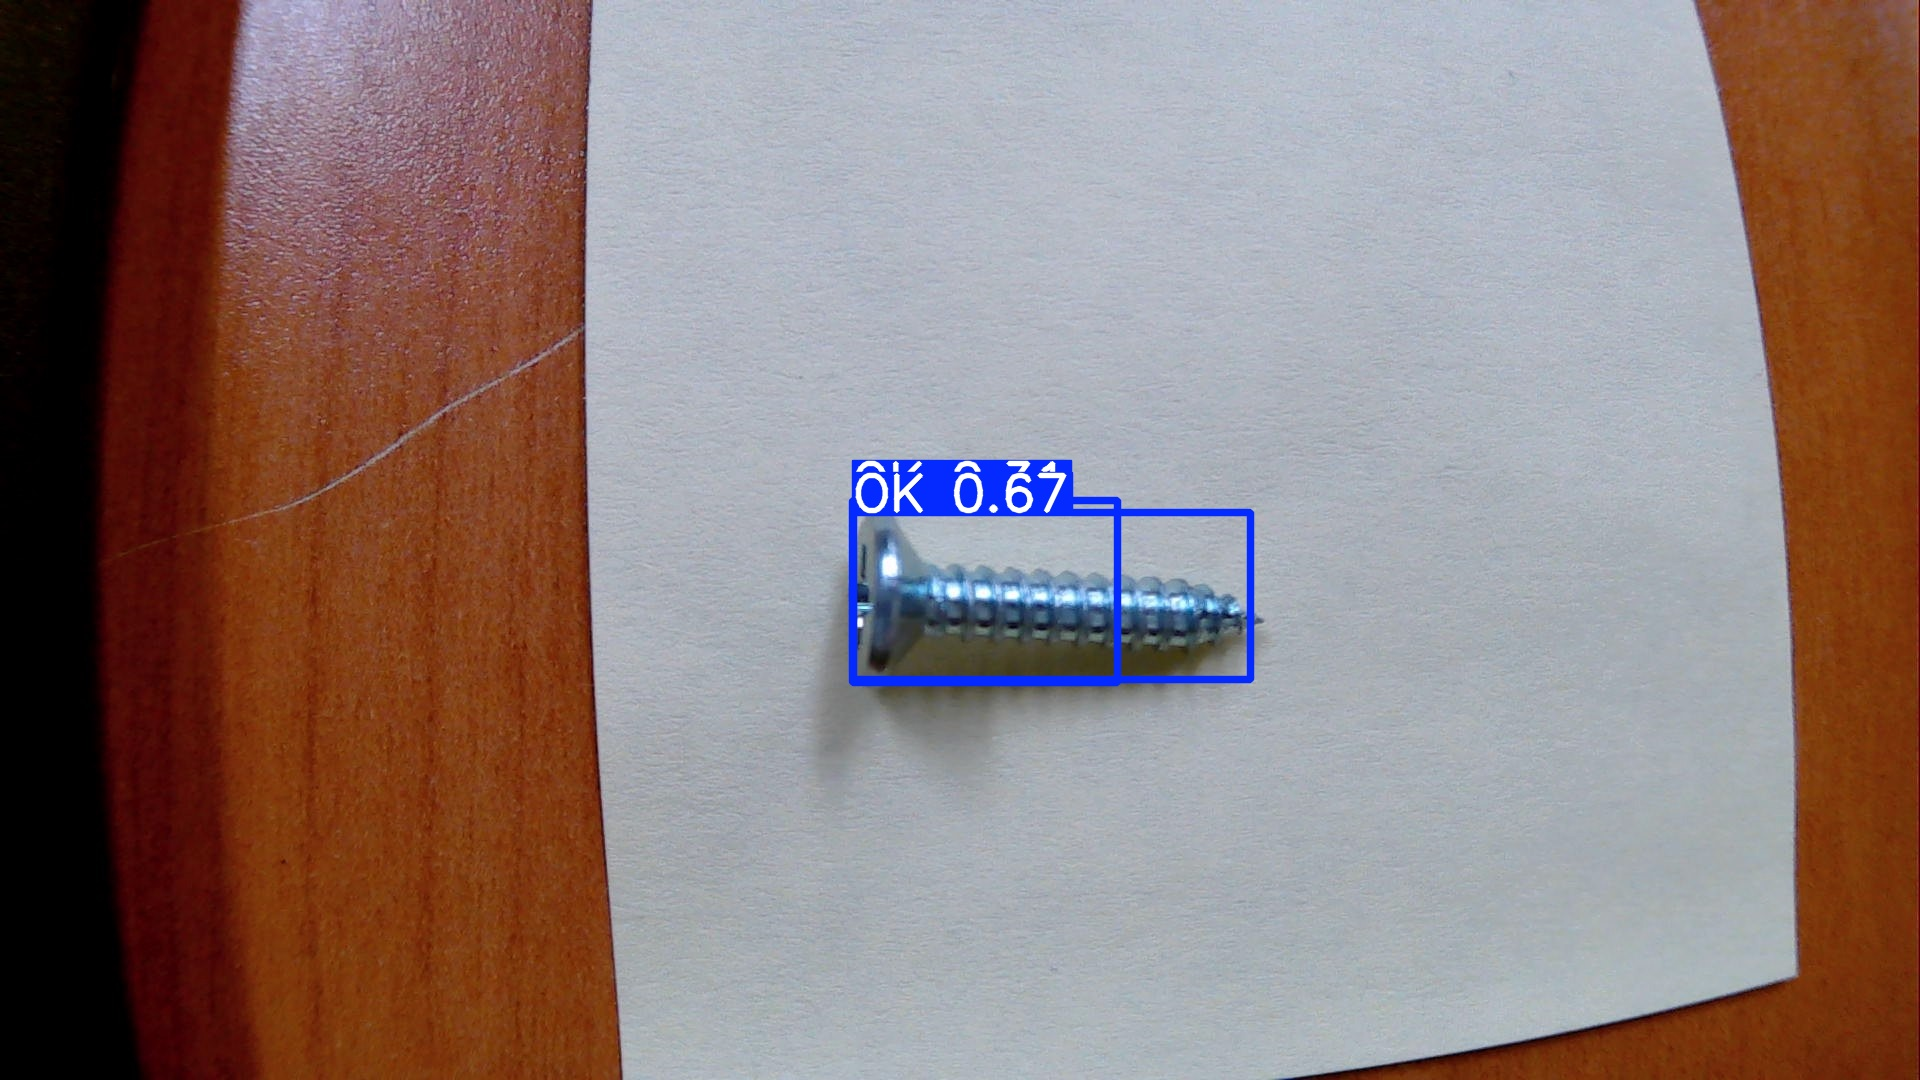

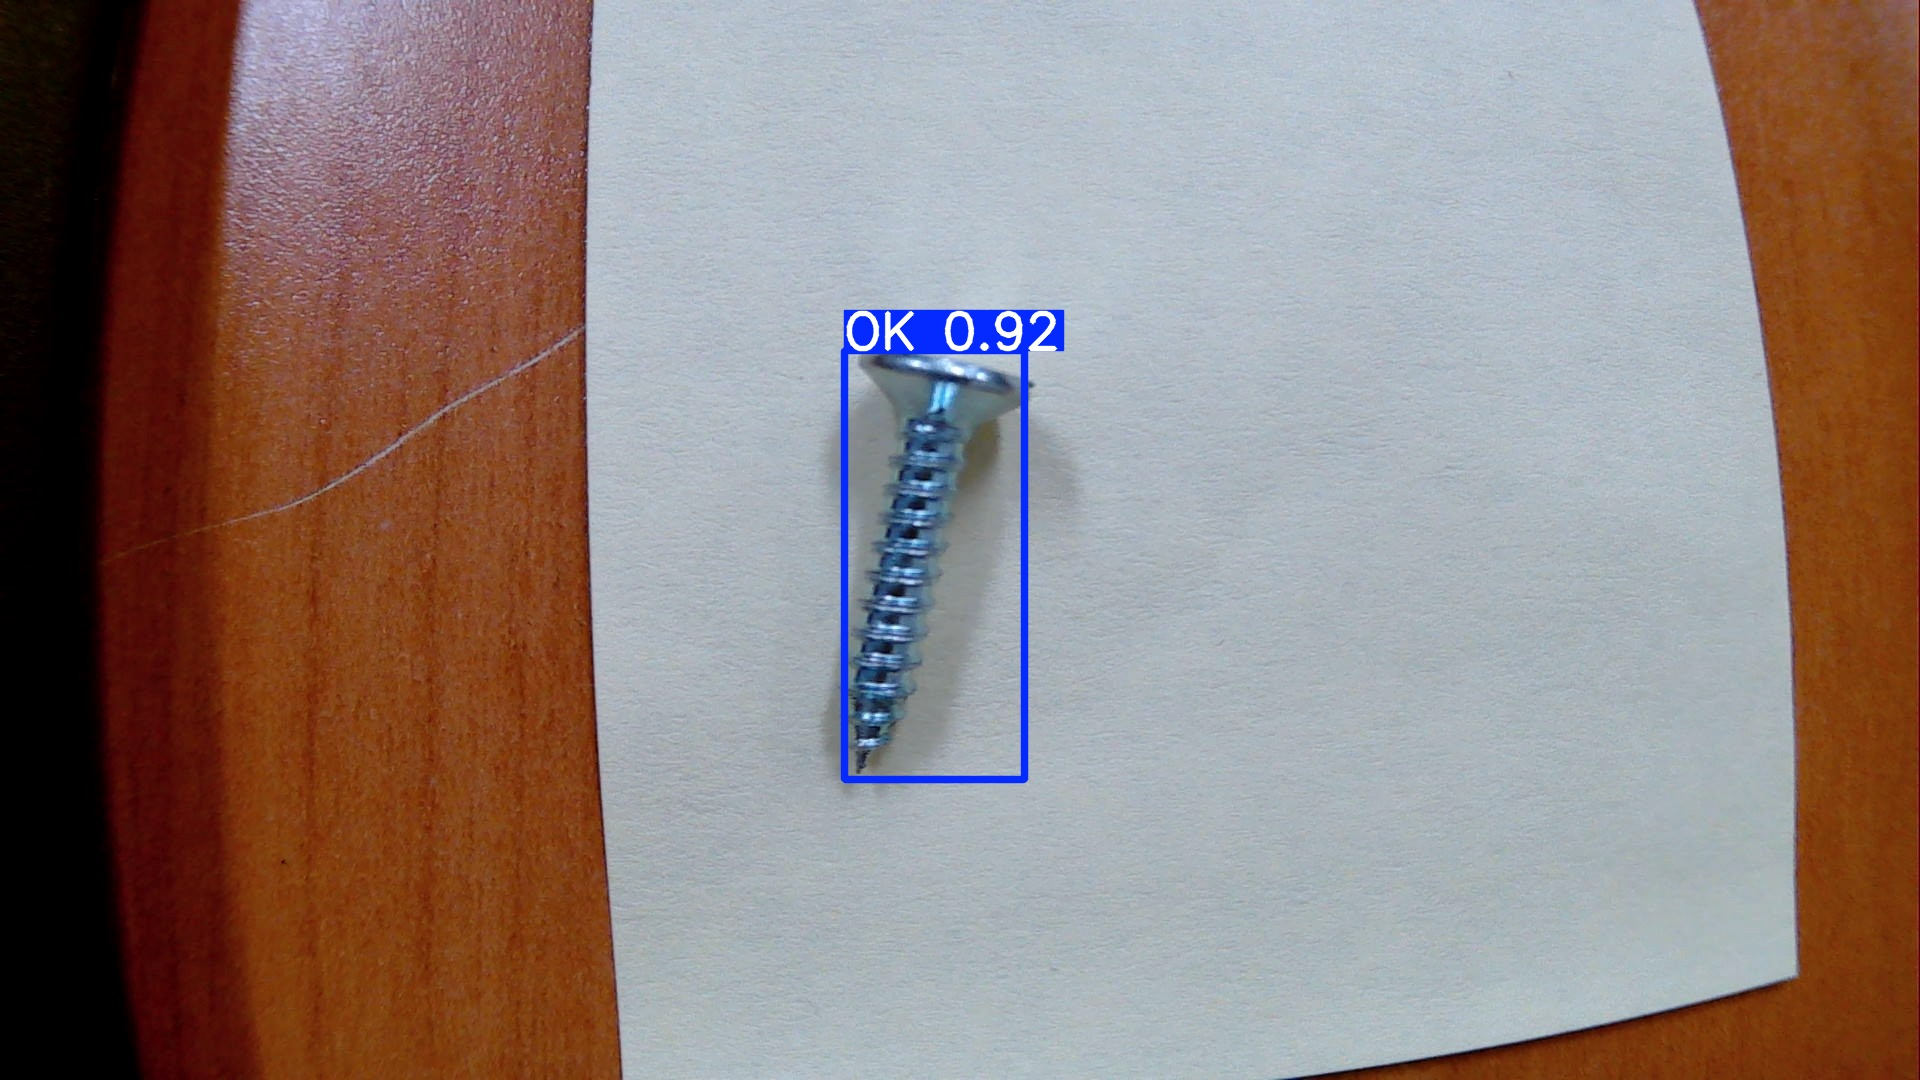

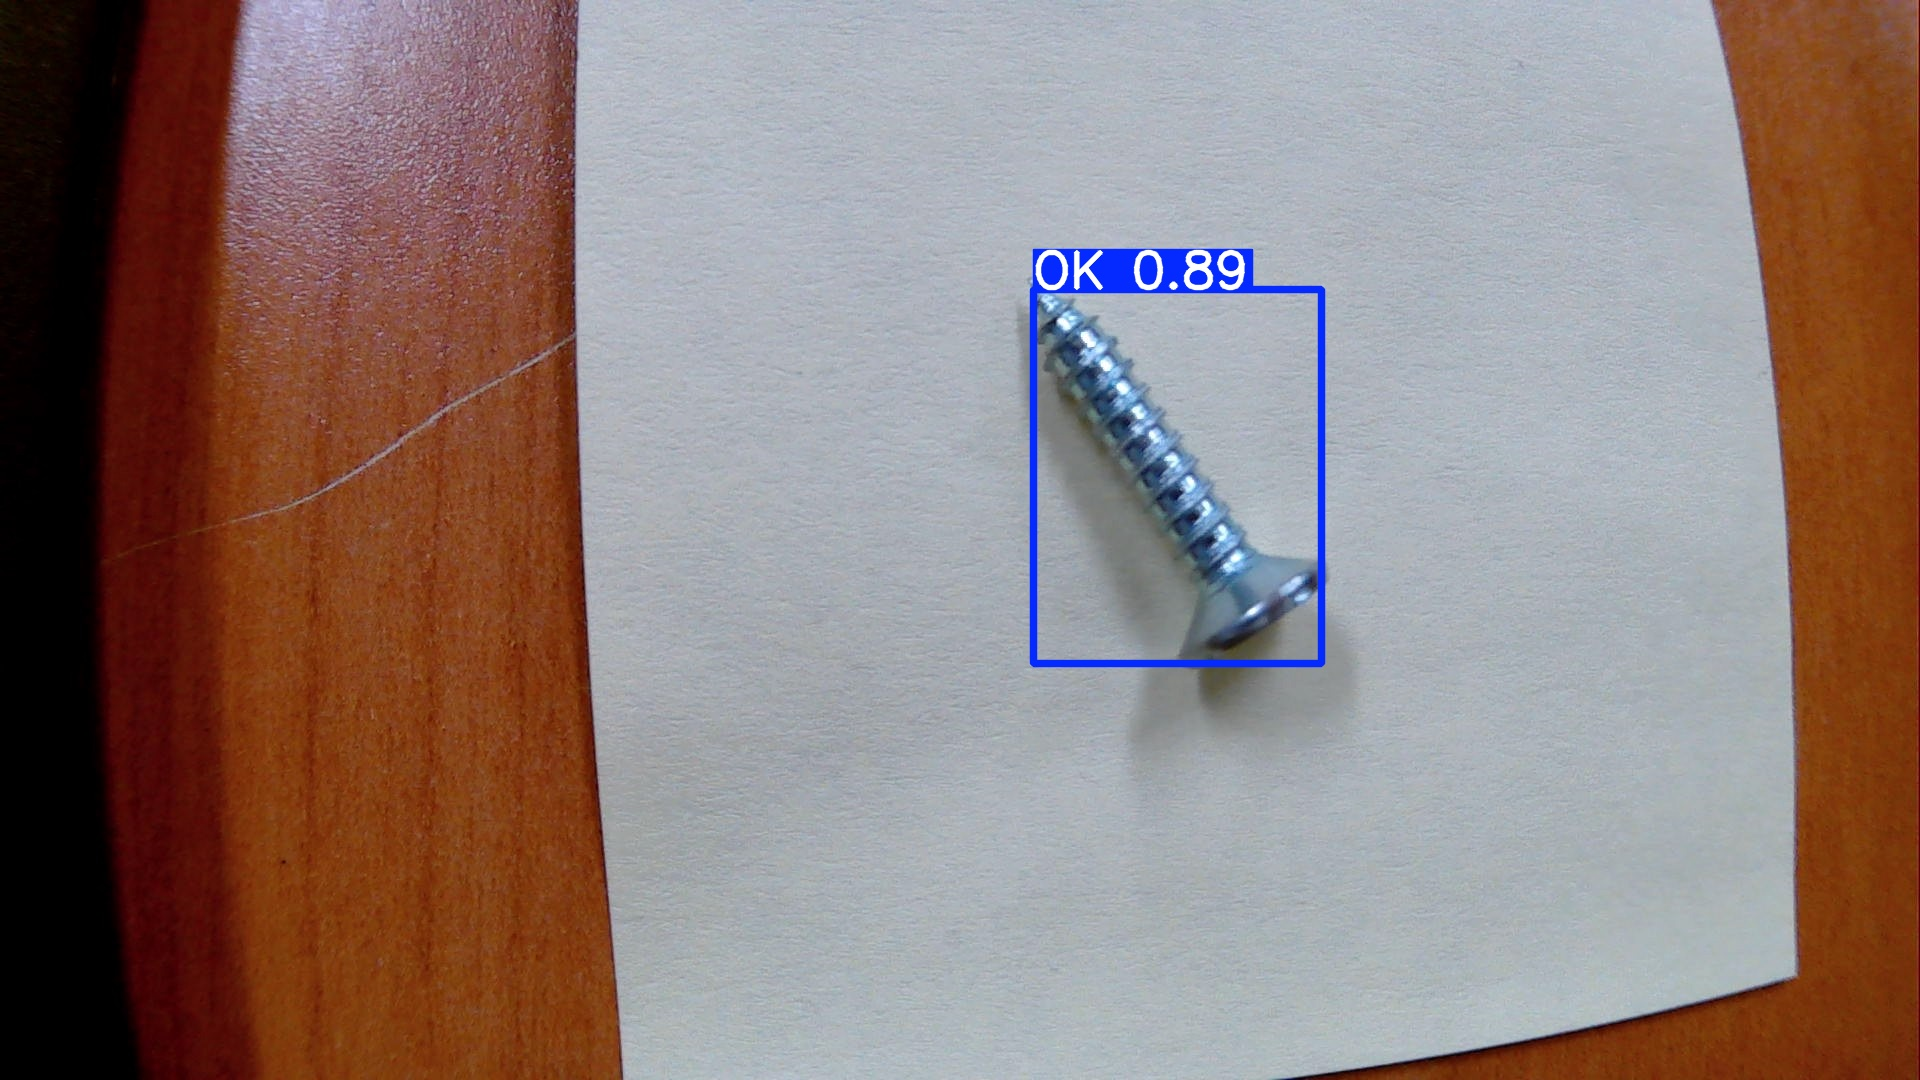

In [ ]:
from IPython.display import Image, display
import glob

images = glob.glob("/content/runs/detect/predict-9/*.jpg")
for img in images:
    display(Image(img))

In [ ]:
from google.colab import files
files.download("/content/runs/detect/screw_final/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>